# Embeddings EDA
This notebook explores the structure of the embedding space, visualize it, and identify any patterns that may exist

In [3]:
import json
from collections import Counter
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

palette = sns.color_palette("rocket", n_colors=7)
sns.set_style("whitegrid", {
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#ffffff",
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_palette(palette)
sns.set_context("notebook", font_scale=1.3, rc={
    "lines.linewidth": 2,
    "axes.linewidth": 1.2,
})
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

TIER_COLORS = {
    "low":           "#e91e63",  # magenta
    "authoritative": "#00bcd4",  # cyan
    "mixed":         "#ffc107",  # amber
}
TIER_ORDER = ["low", "authoritative", "mixed"]

In [4]:
from qdrant_client.models import Distance, VectorParams
from qdrant_client import QdrantClient
from config import COVID_COLLECTIONS, PHASES_BY_NAME, PANDEMIC_PHASES
phase_order = [p.name for p in PANDEMIC_PHASES]

client = QdrantClient(url="http://localhost:6333")
collections = client.get_collections()
print("Collections:")
for collection in collections.collections:
    print(f"- {collection.name}")

Collections:
- credleaf


In [5]:
COLLECTION_NAME = "credleaf"
collection_info = client.get_collection(COLLECTION_NAME)
print(f"Collection: {COLLECTION_NAME}")
print(f"Vector size: {collection_info.config.params.vectors.size}")
print(f"Distance metric: {collection_info.config.params.vectors.distance}")
print(f"Points count: {collection_info.points_count}")
print(f"Indexed points: {collection_info.indexed_vectors_count}")

Collection: credleaf
Vector size: 1024
Distance metric: Cosine
Points count: 82066
Indexed points: 80972


In [6]:
from credibility.registry import CredibilityRegistry, normalize_host
from config import PROCESSED_DIR
def load_metadata_to_df(collection_name, limit=50000, include_vectors=True):
    """Load all payload data into a pandas DataFrame with credibility"""
    scroll_result = client.scroll(
        collection_name=collection_name,
        limit=limit,
        with_payload=True,
        with_vectors=include_vectors
    )
    
    points = scroll_result[0]
    
    records = []
    vectors_list = []
    
    for point in points:
        record = point.payload.copy()
        record["point_id"] = point.id
        records.append(record)
        
        if include_vectors and point.vector:
            # Extract vector (handle different qdrant response formats)
            if isinstance(point.vector, dict):
                vector = point.vector.get('', point.vector.get('dense', None))
            else:
                vector = point.vector
            vectors_list.append(vector)
    
    df = pd.DataFrame(records)
    
    # Convert timestamp if present
    if "capture_timestamp" in df.columns:
        df["capture_timestamp"] = pd.to_datetime(df["capture_timestamp"], errors="coerce")
    
    # Add credibility tier
    print("Adding credibility tiers...")
    
    # Try to load pre-built registry
    registry_path = PROCESSED_DIR / "credibility.json"
    
    if registry_path.exists():
        registry = CredibilityRegistry.load(registry_path)
        print(f"✅ Loaded credibility registry: {registry_path}")
    else:
        registry = CredibilityRegistry()
        print("⚠️ No credibility registry found; using fallback")
    
    # Fallback: use collection tier from config if available
    def get_tier(row):
        tier = registry.lookup(row.get("seed_url", ""))
        if tier == "unknown":
            # Fall back to collection tier if config exists
            if 'COVID_COLLECTIONS' in dir() and row.get("collection_id"):
                coll = COVID_COLLECTIONS.get(row["collection_id"])
                tier = coll.credibility_tier if coll else "unknown"
        return tier
    
    df["credibility_tier"] = df.apply(get_tier, axis=1)
    
    # Map to your tier colors
    df["tier_color"] = df["credibility_tier"].map(TIER_COLORS)
    
    print(f"\n✅ Loaded {len(df)} vectors from {collection_name}")
    print(f"📋 Columns: {list(df.columns)}")
    print(f"\n📊 Credibility distribution:")
    print(df["credibility_tier"].value_counts())
    
    if include_vectors:
        vectors_array = np.array(vectors_list) if vectors_list else np.array([])
        return df, vectors_array
    
    return df

# Load data with vectors
COLLECTION_NAME = "credleaf"  # or whatever your collection is called
df, vectors = load_metadata_to_df(COLLECTION_NAME, limit=50000, include_vectors=True)

print(f"\nVector shape: {vectors.shape}")

Adding credibility tiers...
✅ Loaded credibility registry: /home/ala-adn/code/credleaf/data/processed/credibility.json

✅ Loaded 50000 vectors from credleaf
📋 Columns: ['collection_id', 'seed_id', 'seed_url', 'phase', 'capture_timestamp', 'capture_url', 'digest', 'chunk_idx', 'total_chunks', 'title', 'language', 'extraction_mode', 'word_count', 'char_count', 'text', 'start_index', 'end_index', 'token_count', 'point_id', 'credibility_tier', 'tier_color']

📊 Credibility distribution:
credibility_tier
mixed            38766
low               9667
authoritative     1567
Name: count, dtype: int64

Vector shape: (50000, 1024)


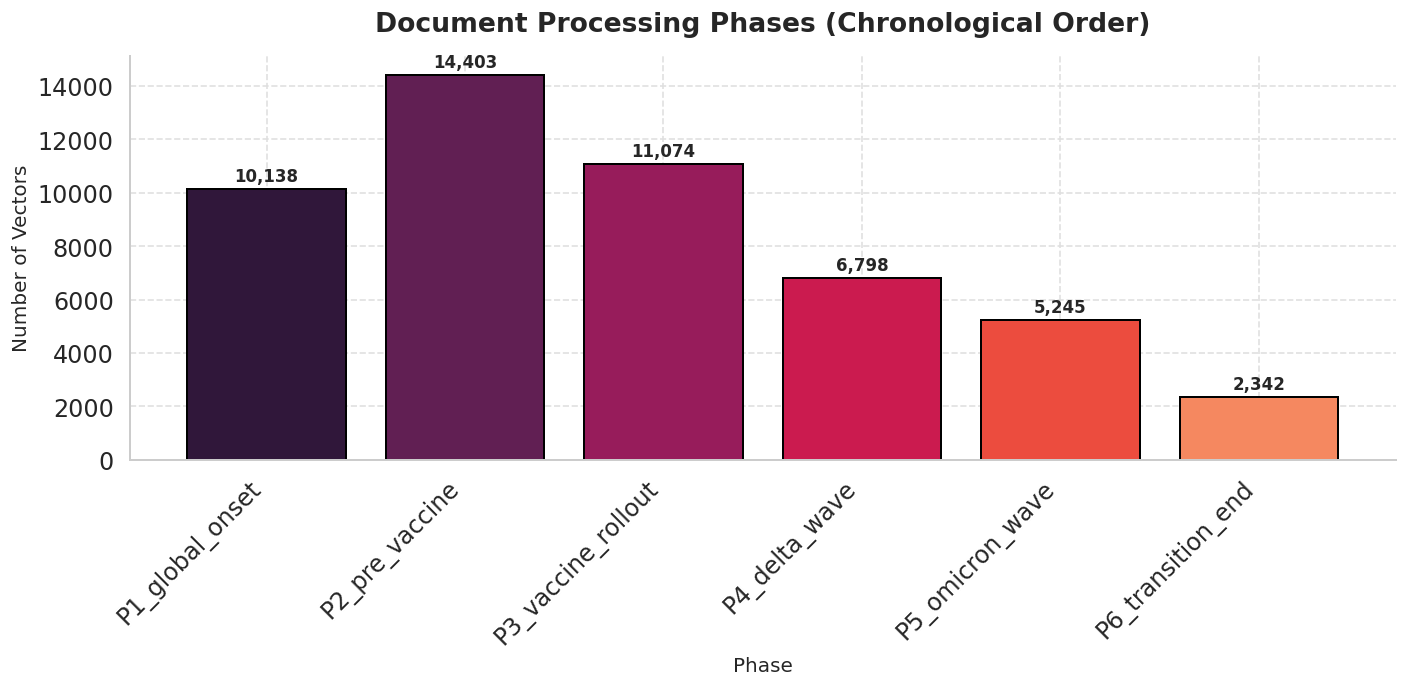

In [7]:
# Cell 3 (updated): Phase distribution with custom order
fig, ax = plt.subplots(figsize=(12, 6))

# Ensure phase is categorical with your order
df['phase_cat'] = pd.Categorical(df['phase'], categories=phase_order, ordered=True)
phase_counts = df['phase_cat'].value_counts().sort_index()

bars = ax.bar(range(len(phase_counts)), phase_counts.values, 
              color=palette[:len(phase_counts)], edgecolor='black', linewidth=1.2)

ax.set_title("Document Processing Phases (Chronological Order)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Phase", fontsize=12)
ax.set_ylabel("Number of Vectors", fontsize=12)
ax.set_xticks(range(len(phase_counts)))
ax.set_xticklabels(phase_counts.index, rotation=45, ha='right')

# Add value labels on bars
for bar, count in zip(bars, phase_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(phase_counts.values)*0.01,
            f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

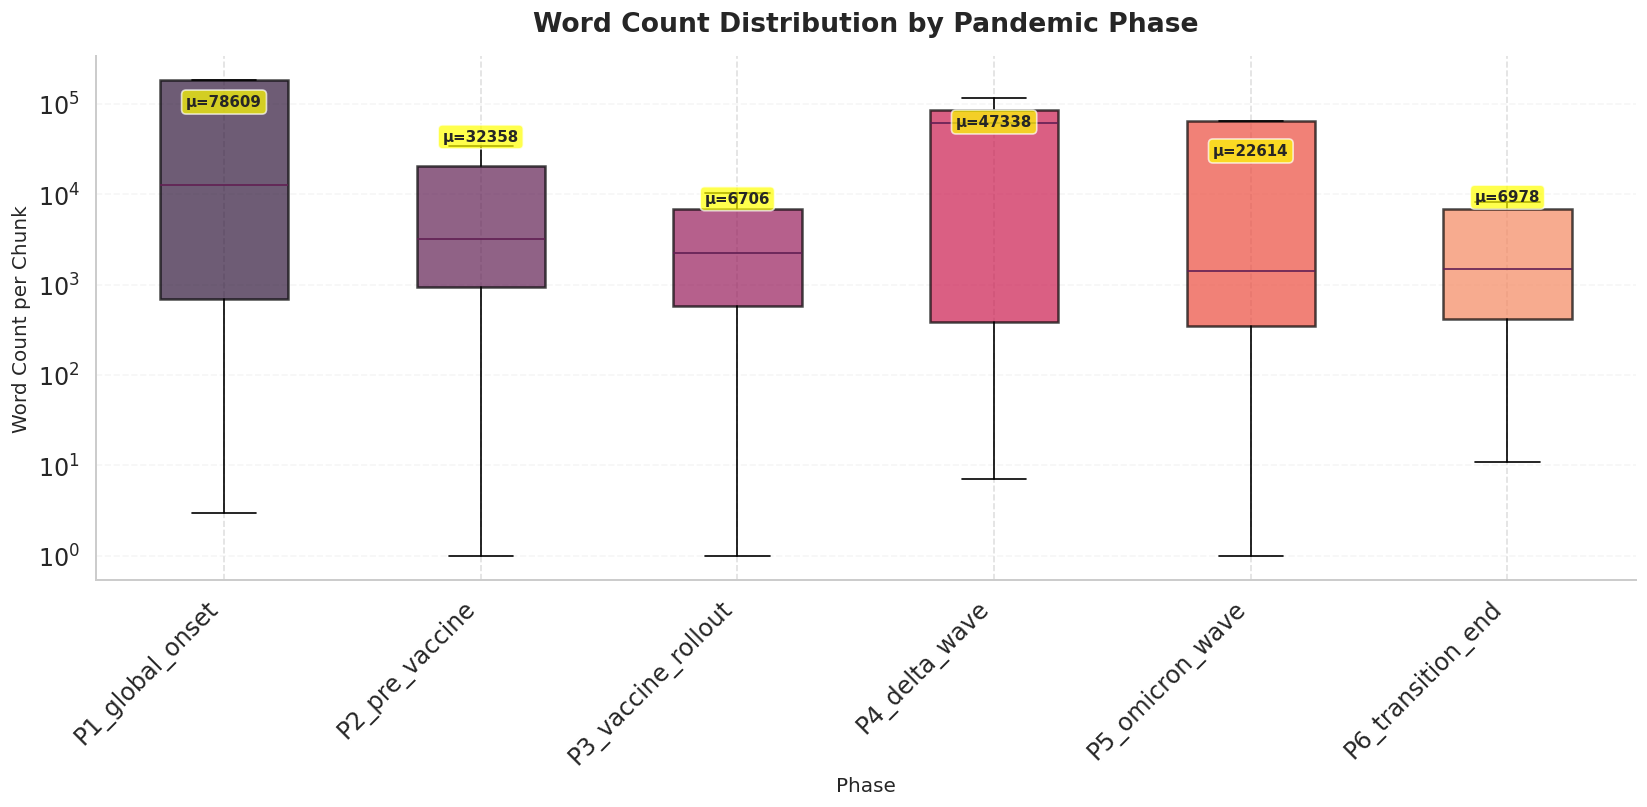

In [8]:
# Cell 5 (updated): Word count distribution across phases (box plot)
fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data in phase order
phase_data = [df[df['phase_cat'] == phase]['word_count'].dropna().values 
              for phase in phase_order if phase in df['phase_cat'].cat.categories]

# Create box plot
bp = ax.boxplot(phase_data, labels=[p for p in phase_order if p in df['phase_cat'].cat.categories],
                patch_artist=True, showfliers=False)

# Color the boxes
for box, color in zip(bp['boxes'], palette[:len(phase_data)]):
    box.set_facecolor(color)
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

ax.set_title("Word Count Distribution by Pandemic Phase", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Phase", fontsize=12)
ax.set_ylabel("Word Count per Chunk", fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

# Add mean value annotations
for i, phase in enumerate([p for p in phase_order if p in df['phase_cat'].cat.categories]):
    mean_val = df[df['phase_cat'] == phase]['word_count'].mean()
    ax.text(i+1, mean_val * 1.1, f'μ={mean_val:.0f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

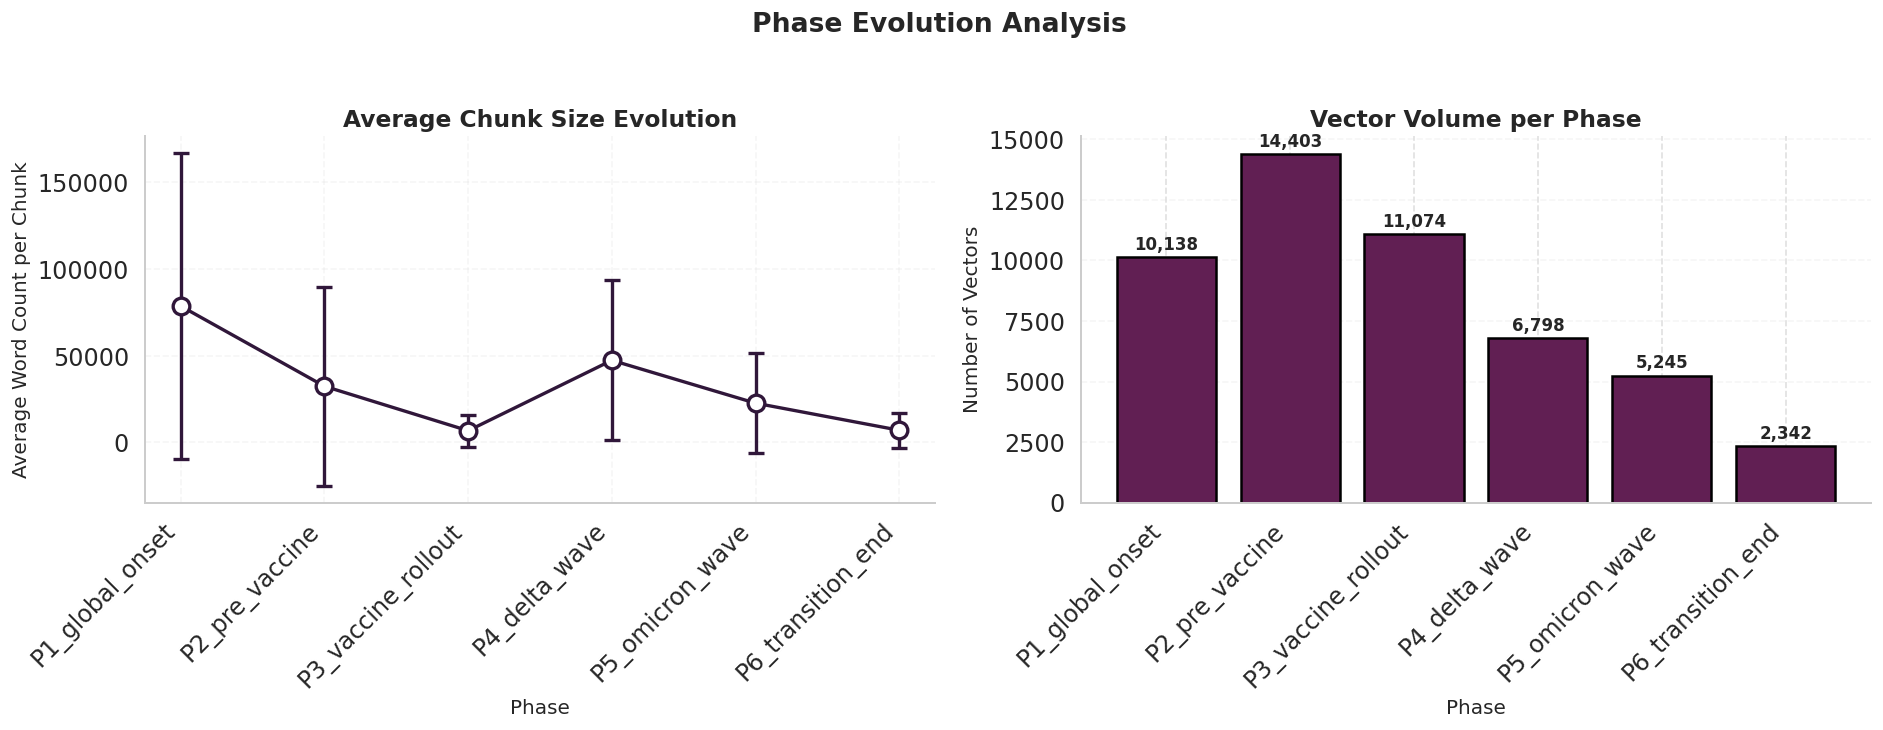

In [9]:
# Cell 7 (fixed): Phase transition analysis - chunk size evolution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Average chunk size over phases
# Drop NaN values and ensure alignment
phase_avg_words = df.groupby('phase_cat')['word_count'].mean().reindex(phase_order)
phase_std_words = df.groupby('phase_cat')['word_count'].std().reindex(phase_order)

# Remove phases with no data
valid_phases = phase_avg_words.dropna().index
valid_avg = phase_avg_words[valid_phases]
valid_std = phase_std_words[valid_phases]

# Create x positions
x_positions = range(len(valid_phases))

axes[0].errorbar(x_positions, 
                 valid_avg.values,
                 yerr=valid_std.values,
                 fmt='o-', capsize=5, capthick=2, markersize=10,
                 color=palette[0], linewidth=2, markerfacecolor='white', markeredgewidth=2)

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(valid_phases, rotation=45, ha='right')
axes[0].set_title("Average Chunk Size Evolution", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Average Word Count per Chunk", fontsize=12)
axes[0].set_xlabel("Phase", fontsize=12)
axes[0].grid(True, alpha=0.3)

# Right plot: Volume of vectors per phase (only phases with data)
phase_counts_phase = df['phase_cat'].value_counts().reindex(valid_phases)

bars = axes[1].bar(range(len(phase_counts_phase)), 
                   phase_counts_phase.values,
                   color=palette[1], edgecolor='black', linewidth=1.5)

axes[1].set_xticks(range(len(phase_counts_phase)))
axes[1].set_xticklabels(phase_counts_phase.index, rotation=45, ha='right')
axes[1].set_title("Vector Volume per Phase", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Number of Vectors", fontsize=12)
axes[1].set_xlabel("Phase", fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, phase_counts_phase.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(phase_counts_phase.values)*0.01,
                 f'{int(count):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle("Phase Evolution Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

valid_mask = ~df["credibility_tier"].isna() & (df["credibility_tier"] != "unknown")
df_clean = df[valid_mask].copy()
vectors_clean = vectors[valid_mask]

print(f"Final shape: {vectors_clean.shape}")
print(f"Credibility distribution in sample:\n{df_clean['credibility_tier'].value_counts()}")

# Standardize vectors for PCA
scaler = StandardScaler()
vectors_scaled = scaler.fit_transform(vectors_clean)

Final shape: (50000, 1024)
Credibility distribution in sample:
credibility_tier
mixed            38766
low               9667
authoritative     1567
Name: count, dtype: int64


Computing PCA with 100 components...


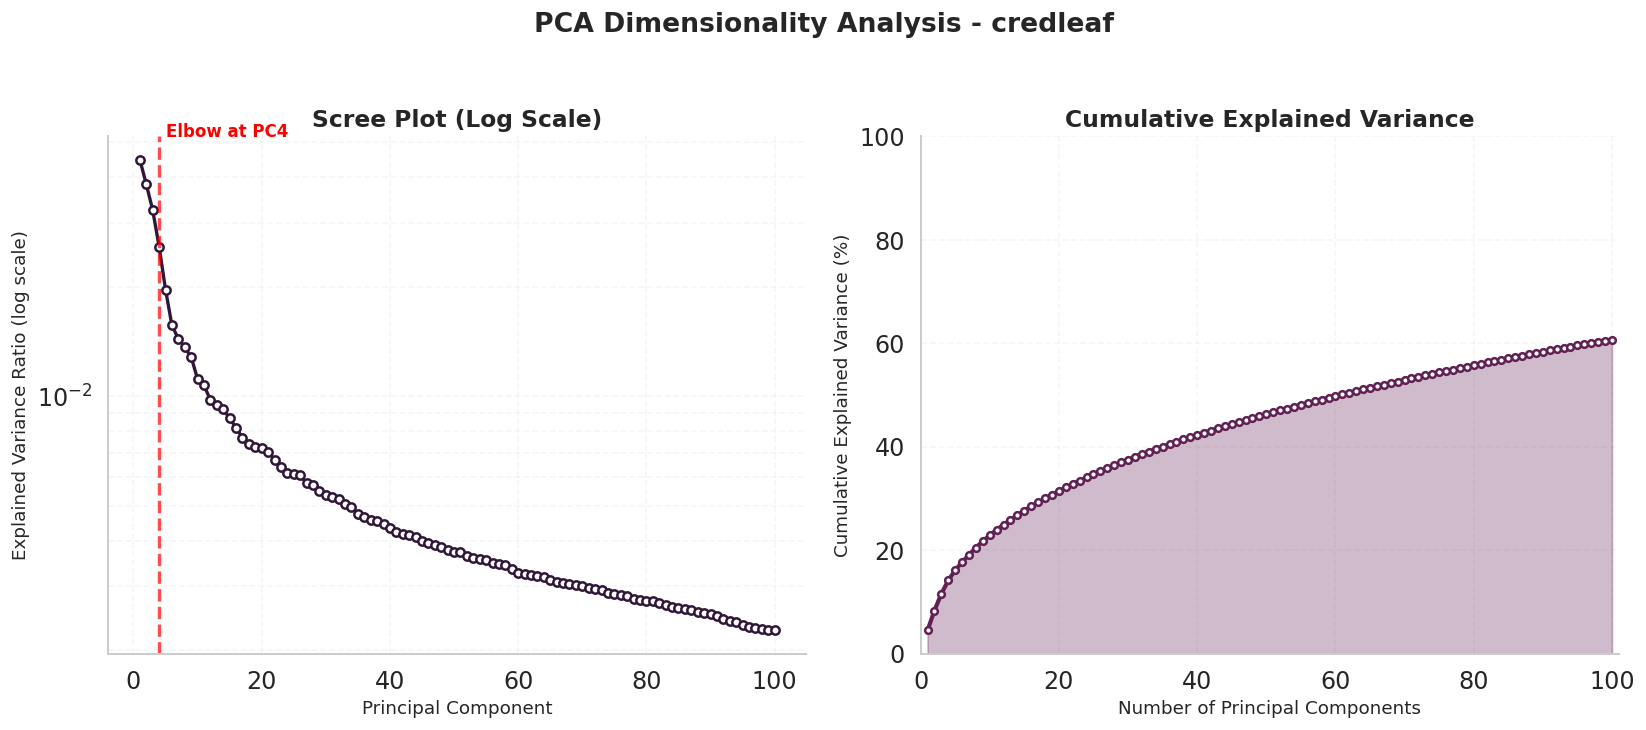

In [12]:
# Cell: Scree Plot with Elbow Detection (Enhanced Version) - FIXED
from scipy.signal import argrelextrema

# Define dimensions
n_dims = min(100, vectors_scaled.shape[1], vectors_scaled.shape[0])
print(f"Computing PCA with {n_dims} components...")

# Fit PCA
pca_full = PCA(n_components=n_dims, random_state=42)
pca_full.fit(vectors_scaled)

# Create dims array and cumulative variance
dims = np.arange(1, n_dims + 1)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Scree plot (log scale)
ax1 = axes[0]
ax1.plot(dims, pca_full.explained_variance_ratio_, 'o-', color=palette[0], 
         linewidth=2, markersize=5, markerfacecolor='white', markeredgewidth=1.5)
ax1.set_yscale('log')
ax1.set_title('Scree Plot (Log Scale)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance Ratio (log scale)', fontsize=11)
ax1.grid(True, alpha=0.3, which='both')

# Find "elbow" point using first derivative
variances = pca_full.explained_variance_ratio_
diff_var = np.diff(variances)  # First derivative
elbow_point = np.argmin(diff_var[:min(20, len(diff_var))]) + 2  # Look within first 20 components

ax1.axvline(x=elbow_point, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.text(elbow_point + 1, variances[elbow_point-1] * 2, 
         f'Elbow at PC{elbow_point}', fontsize=10, color='red', fontweight='bold')

# Right plot: Cumulative variance with dimension recommendations
ax2 = axes[1]
ax2.plot(dims, cumulative_variance * 100, 'o-', color=palette[1], 
         linewidth=2.5, markersize=4, markerfacecolor='white', markeredgewidth=1.5)

# Fill area under curve
ax2.fill_between(dims, cumulative_variance * 100, alpha=0.3, color=palette[1])

ax2.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Principal Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax2.set_xlim(0, n_dims + 1)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)


plt.suptitle(f'PCA Dimensionality Analysis - {COLLECTION_NAME}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Cell 1: Compute Projections
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tqdm.notebook import tqdm

# Dictionary to store the resulting coordinate arrays
projections = {}

# Variables to store fitted models if you need their attributes later
models = {}

# Define the sequence of projection tasks
tasks = ["PCA", "t-SNE", "UMAP"]

with tqdm(total=len(tasks), desc="Computing Projections") as pbar:
    # 1. PCA
    pbar.set_postfix_str("Running PCA...")
    pca = PCA(n_components=2, random_state=42)
    projections["PCA"] = pca.fit_transform(vectors_scaled)
    models["PCA"] = pca
    pbar.update(1)

    # 2. t-SNE
    pbar.set_postfix_str("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
    projections["t-SNE"] = tsne.fit_transform(vectors_scaled)
    models["t-SNE"] = tsne
    pbar.update(1)

    # 3. UMAP
    pbar.set_postfix_str("Running UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, verbose=True)
    projections["UMAP"] = umap_reducer.fit_transform(vectors_scaled)
    models["UMAP"] = umap_reducer
    pbar.update(1)
    
    pbar.set_postfix_str("All projections complete!")

print(f"PCA Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"t-SNE KL divergence: {tsne.kl_divergence_:.2f}")

Computing Projections:   0%|          | 0/3 [00:00<?, ?it/s]

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.024s...
[t-SNE] Computed neighbors for 50000 samples in 29.974s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sa

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Jun  9 19:13:02 2026 Finished embedding
PCA Explained variance: 8.30%
t-SNE KL divergence: 2.58


In [35]:
# Cell 2: True Gaussian KDE Plotly Function
import numpy as np
from scipy.stats import gaussian_kde
import plotly.graph_objects as go
import matplotlib.colors as mc

# Define default opacities
DEFAULT_TIER_OPACITY = {
    "low": 0.6,
    "authoritative": 0.5,
    "mixed": 0.6
}

def get_transparent_colorscale(color_name):
    """Converts a color to a Plotly colorscale (transparent to opaque) for smooth overlaid heatmaps."""
    try:
        rgb = mc.to_rgb(color_name)
        r, g, b = [int(c * 255) for c in rgb]
        return [[0, f'rgba({r},{g},{b},0)'], [1, f'rgba({r},{g},{b},1)']]
    except:
        return [[0, 'rgba(255,255,255,0)'], [1, color_name]]

def plot_interactive_kde(proj_coords, df, method_name, axis_labels=None, title_suffix="", tier_opacities=None):
    """
    Generates an interactive Plotly plot using true Gaussian Kernel Density Estimation.
    Clicking items in the legend will toggle their visibility.
    """
    if tier_opacities is None:
        tier_opacities = DEFAULT_TIER_OPACITY
        
    if axis_labels is None:
        axis_labels = (f"{method_name} Dimension 1", f"{method_name} Dimension 2")

    fig = go.Figure()

    # Define the bounding box for the KDE grid (with 10% padding)
    x_min, x_max = proj_coords[:, 0].min(), proj_coords[:, 0].max()
    y_min, y_max = proj_coords[:, 1].min(), proj_coords[:, 1].max()
    x_pad = (x_max - x_min) * 0.1
    y_pad = (y_max - y_min) * 0.1
    
    # Create a 100x100 grid to evaluate the true KDE surface
    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 100)
    y_grid = np.linspace(y_min - y_pad, y_max + y_pad, 100)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_positions = np.vstack([xx.ravel(), yy.ravel()])

    # Iterate through tiers to compute and plot true KDE
    for tier in TIER_ORDER:
        mask = df["credibility_tier"] == tier
        if mask.any():
            x_data = proj_coords[mask, 0]
            y_data = proj_coords[mask, 1]
            
            # Scipy's KDE requires at least 2 variance-producing points
            if len(x_data) > 2:
                # 1. Calculate the true Gaussian KDE
                kernel = gaussian_kde(np.vstack([x_data, y_data]))
                
                # 2. Evaluate the kernel on our grid and reshape back to 100x100
                z_surface = kernel(grid_positions).reshape(100, 100)

                base_color = TIER_COLORS.get(tier, 'blue')
                colorscale = get_transparent_colorscale(base_color)

                # 3. Plot the true surface using go.Contour
                fig.add_trace(go.Contour(
                    x=x_grid,
                    y=y_grid,
                    z=z_surface,
                    name=tier.capitalize(),
                    showlegend=True,
                    colorscale=colorscale,
                    showscale=False,
                    contours=dict(
                        coloring='fill',
                        showlines=False
                    ),
                    opacity=tier_opacities.get(tier, 0.5),
                    hoverinfo='name'
                ))
            else:
                # Fallback: Just plot scatter if there aren't enough points for a KDE
                fig.add_trace(go.Scatter(
                    x=x_data, y=y_data, mode='markers', name=tier.capitalize() + " (Scatter)",
                    marker=dict(color=TIER_COLORS.get(tier, 'blue'), size=8), showlegend=True
                ))

    # Format the title
    title_html = f"<b>{method_name} True Gaussian KDE Map</b><br><sup>Collected from {COLLECTION_NAME} {title_suffix}</sup>"

    fig.update_layout(
        title=title_html,
        xaxis_title=axis_labels[0],
        yaxis_title=axis_labels[1],
        legend_title_text="Credibility Tier",
        legend=dict(itemsizing='constant'),
        template="plotly_white",
        width=1000,
        height=800,
        hovermode="closest"
    )

    return fig

In [36]:
# Cell 3: Display Projections as KDE Heatmaps

# 1. PCA KDE Plot
pca_explained = models["PCA"].explained_variance_ratio_
pca_axes = (
    f"PC1 ({pca_explained[0]:.1%} variance)", 
    f"PC2 ({pca_explained[1]:.1%} variance)"
)
fig_pca = plot_interactive_kde(
    proj_coords=projections["PCA"], 
    df=df_clean, 
    method_name="PCA", 
    axis_labels=pca_axes,
    title_suffix=f"(Total Variance: {pca_explained.sum():.2%})"
)
fig_pca.show()


# 2. t-SNE KDE Plot
fig_tsne = plot_interactive_kde(
    proj_coords=projections["t-SNE"], 
    df=df_clean, 
    method_name="t-SNE",
    title_suffix="(perplexity=30)"
)
fig_tsne.show()


# 3. UMAP KDE Plot
fig_umap = plot_interactive_kde(
    proj_coords=projections["UMAP"], 
    df=df_clean, 
    method_name="UMAP",
    title_suffix="(n_neighbors=15)"
)
fig_umap.show()